# 07 — Normalização e Padronização

## Instagram & Bem-Estar: O Custo Psicológico das Redes Sociais

**Objetivo:** Neste notebook, iremos realizar a normalização e padronização das variáveis numéricas do conjunto de dados de utilização do Instagram e estilo de vida. Em seguida, analisaremos as distribuições dos dados transformados.

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler, StandardScaler

# Carregar o conjunto de dados
df = pd.read_csv('../data/instagram_usage_lifestyle.csv')
print("Forma do conjunto de dados:", df.shape)
print("Primeiras 5 linhas:")
df.head()

Forma do conjunto de dados: (1547896, 58)
Primeiras 5 linhas:


,user_id,app_name,age,gender,country,urban_rural,income_level,employment_status,education_level,relationship_status,...,last_login_date,average_session_length_minutes,content_type_preference,preferred_content_theme,privacy_setting_level,two_factor_auth_enabled,biometric_login_used,linked_accounts_count,subscription_status,user_engagement_score
0,1,Instagram,51,Female,India,Rural,High,Retired,Bachelor’s,Single,...,2025-11-02,5.0,Mixed,Tech,Private,Yes,No,0,Free,7.83
1,2,Instagram,64,Female,United Kingdom,Urban,Middle,Full-time employed,Other,Divorced,...,2025-03-22,14.8,Photos,Fashion,Public,No,No,3,Free,1.43
2,3,Instagram,41,Female,Canada,Urban,Middle,Student,Bachelor’s,In a relationship,...,2025-08-10,5.0,Mixed,Other,Public,Yes,Yes,1,Free,9.67
3,4,Instagram,27,Non-binary,South Korea,Urban,Middle,Unemployed,Master’s,In a relationship,...,2025-03-31,25.9,Stories,Tech,Private,No,No,1,Free,0.94
4,5,Instagram,55,Male,India,Urban,Upper-middle,Full-time employed,Bachelor’s,Single,...,2025-03-19,13.1,Videos,Food,Public,Yes,No,0,Free,1.03


In [8]:
# Selecionar colunas numéricas para transformação
numeric_cols = [
    'age', 'exercise_hours_per_week', 'sleep_hours_per_night', 'perceived_stress_score', 
    'self_reported_happiness', 'body_mass_index', 'blood_pressure_systolic', 'blood_pressure_diastolic', 
    'daily_steps_count', 'weekly_work_hours', 'hobbies_count', 'social_events_per_month', 
    'books_read_per_year', 'volunteer_hours_per_month', 'travel_frequency_per_year', 
    'daily_active_minutes_instagram', 'sessions_per_day', 'posts_created_per_week', 
    'reels_watched_per_day', 'stories_viewed_per_day', 'likes_given_per_day', 
    'comments_written_per_day', 'dms_sent_per_week', 'dms_received_per_week', 
    'ads_viewed_per_day', 'ads_clicked_per_day', 'time_on_feed_per_day', 
    'time_on_explore_per_day', 'time_on_messages_per_day', 'time_on_reels_per_day', 
    'followers_count', 'following_count', 'notification_response_rate', 
    'account_creation_year', 'average_session_length_minutes', 'user_engagement_score', 
    'linked_accounts_count'
]

df_numeric = df[numeric_cols]
print("Colunas numéricas selecionadas:", len(numeric_cols))
df_numeric.head()

Colunas numéricas selecionadas: 37


,age,exercise_hours_per_week,sleep_hours_per_night,perceived_stress_score,self_reported_happiness,body_mass_index,blood_pressure_systolic,blood_pressure_diastolic,daily_steps_count,weekly_work_hours,...,time_on_explore_per_day,time_on_messages_per_day,time_on_reels_per_day,followers_count,following_count,notification_response_rate,account_creation_year,average_session_length_minutes,user_engagement_score,linked_accounts_count
0,51,7.2,7.7,3,8,20.8,148,86,8107,49.9,...,1,1,2,374,647,0.34,2015,5.0,7.83,0
1,64,10.9,8.6,1,1,23.5,133,84,8059,15.6,...,19,16,19,2585,3511,0.56,2018,14.8,1.43,3
2,41,5.0,6.7,4,10,28.6,135,88,7872,31.8,...,1,1,1,3414,6761,0.73,2011,5.0,9.67,1
3,27,10.6,6.5,18,1,22.5,105,73,7801,43.4,...,64,52,64,617,1193,0.73,2019,25.9,0.94,1
4,55,7.7,6.8,19,1,28.1,146,90,8005,50.2,...,55,22,55,1157,1072,0.65,2017,13.1,1.03,0


In [9]:
# Normalização (Escala Min-Max)
minmax_scaler = MinMaxScaler()
df_normalized = pd.DataFrame(minmax_scaler.fit_transform(df_numeric), columns=numeric_cols)

print("Dados normalizados (primeiras 5 linhas):")
df_normalized.head()

Dados normalizados (primeiras 5 linhas):


,age,exercise_hours_per_week,sleep_hours_per_night,perceived_stress_score,self_reported_happiness,body_mass_index,blood_pressure_systolic,blood_pressure_diastolic,daily_steps_count,weekly_work_hours,...,time_on_explore_per_day,time_on_messages_per_day,time_on_reels_per_day,followers_count,following_count,notification_response_rate,account_creation_year,average_session_length_minutes,user_engagement_score,linked_accounts_count
0,0.730769,0.298755,0.671429,0.075,0.777778,0.193333,0.840580,0.666667,0.596472,0.62375,...,0.000000,0.000000,0.004525,0.001743,0.062826,0.34,0.333333,0.000000,0.397778,0.0
1,0.980769,0.452282,0.800000,0.025,0.000000,0.283333,0.623188,0.615385,0.543550,0.19500,...,0.105882,0.109489,0.081448,0.012332,0.349800,0.56,0.533333,0.208511,0.042222,0.6
2,0.538462,0.207469,0.528571,0.100,1.000000,0.453333,0.652174,0.717949,0.337376,0.39750,...,0.000000,0.000000,0.000000,0.016303,0.675451,0.73,0.066667,0.000000,0.500000,0.2
3,0.269231,0.439834,0.500000,0.450,0.000000,0.250000,0.217391,0.333333,0.259096,0.54250,...,0.370588,0.372263,0.285068,0.002907,0.117535,0.73,0.600000,0.444681,0.015000,0.2
4,0.807692,0.319502,0.542857,0.475,0.000000,0.436667,0.811594,0.769231,0.484013,0.62750,...,0.317647,0.153285,0.244344,0.005493,0.105411,0.65,0.466667,0.172340,0.020000,0.0


In [10]:
# Padronização (Z-score)
standard_scaler = StandardScaler()
df_standardized = pd.DataFrame(standard_scaler.fit_transform(df_numeric), columns=numeric_cols)

print("Dados padronizados (primeiras 5 linhas):")
df_standardized.head()

Dados padronizados (primeiras 5 linhas):


,age,exercise_hours_per_week,sleep_hours_per_night,perceived_stress_score,self_reported_happiness,body_mass_index,blood_pressure_systolic,blood_pressure_diastolic,daily_steps_count,weekly_work_hours,...,time_on_explore_per_day,time_on_messages_per_day,time_on_reels_per_day,followers_count,following_count,notification_response_rate,account_creation_year,average_session_length_minutes,user_engagement_score,linked_accounts_count
0,0.785547,0.014149,0.638609,-1.435676,0.870775,-1.056499,1.163374,0.562826,1.195731,0.990120,...,-1.444142,-1.489905,-1.541160,-0.525143,-0.711482,-0.554882,-0.542261,-1.783248,3.412266,-1.460924
1,1.635524,0.940410,1.458955,-1.604700,-1.567204,-0.377456,0.421057,0.389647,0.658803,-2.440800,...,-0.734303,-0.790463,-1.060225,0.124766,0.329246,0.206936,0.108254,-0.656481,-0.118411,0.757916
2,0.131718,-0.536601,-0.272887,-1.351163,1.567340,0.905180,0.520032,0.736005,-1.432976,-0.820365,...,-1.444142,-1.489905,-1.569450,0.368446,1.510239,0.795614,-1.409614,-1.783248,4.427335,-0.721311
3,-0.783643,0.865308,-0.455187,-0.167989,-1.567204,-0.628954,-0.964603,-0.562839,-2.227181,0.339946,...,1.040294,0.888196,0.212839,-0.453714,-0.513075,0.795614,0.325092,0.619755,-0.388729,-0.721311
4,1.047078,0.139320,-0.181738,-0.083476,-1.567204,0.779431,1.064399,0.909184,0.054760,1.020128,...,0.685374,-0.510687,-0.041774,-0.294985,-0.557044,0.518589,-0.108584,-0.851941,-0.339079,-1.460924


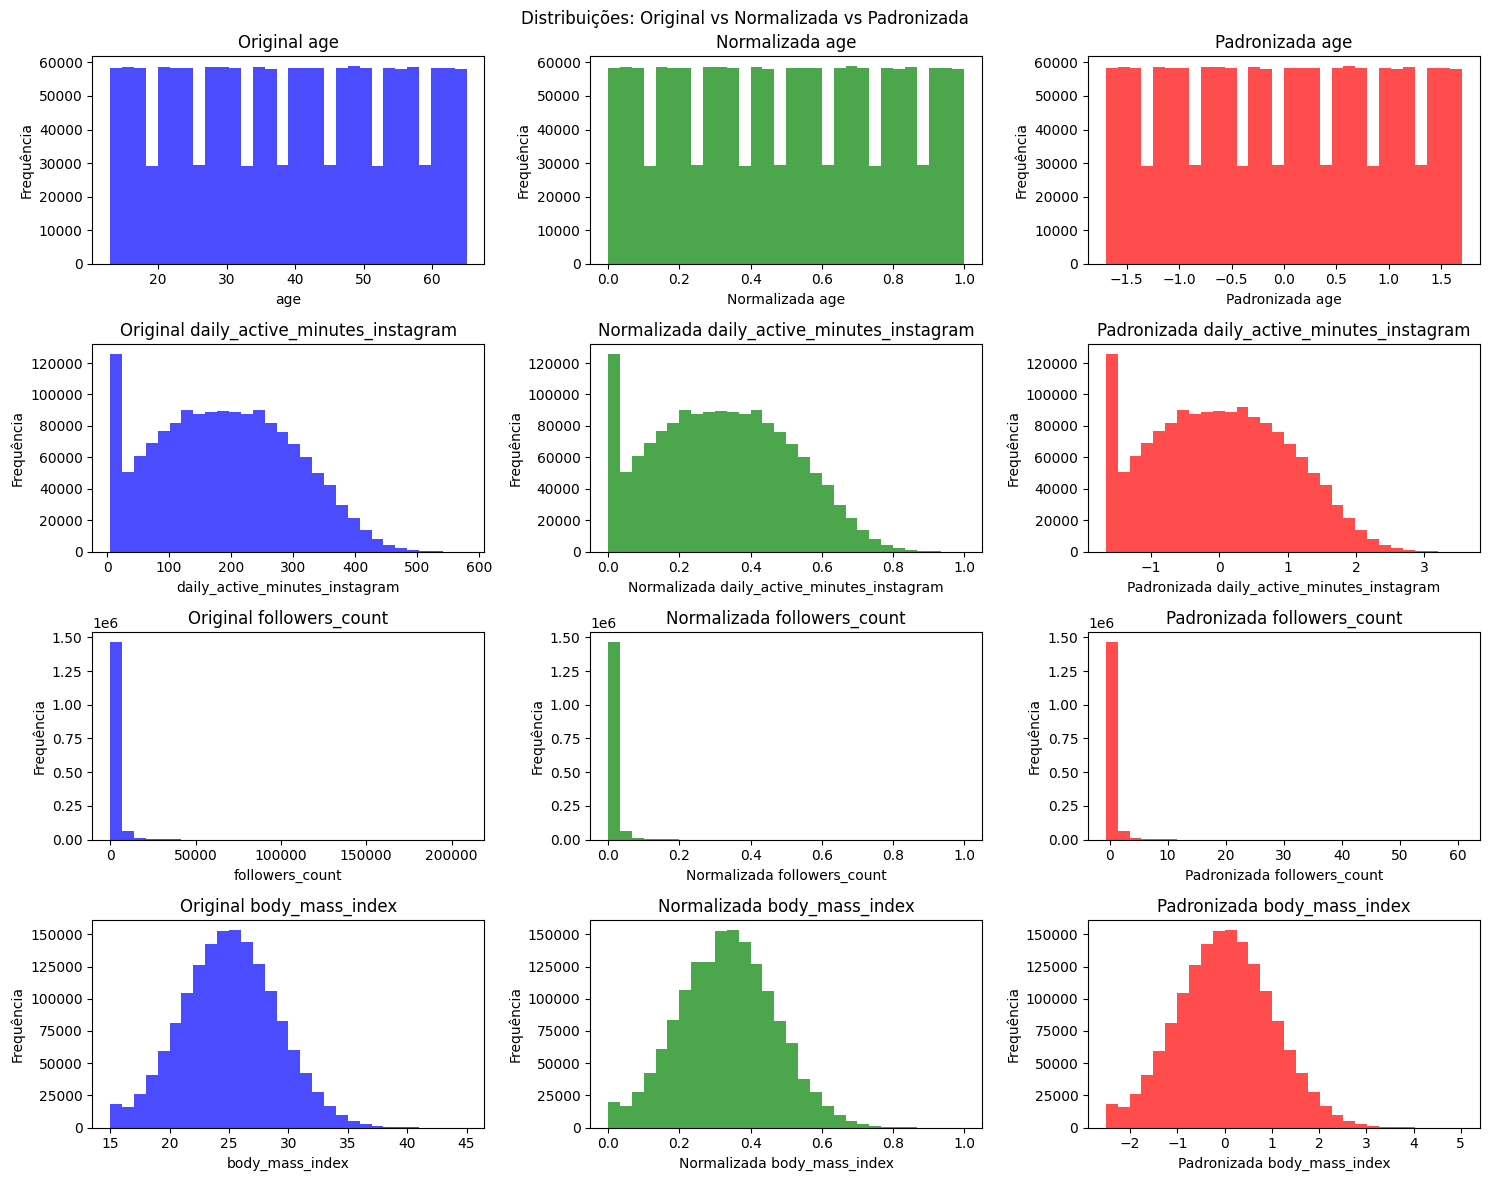

In [11]:
# Analisar distribuições
# Selecionar algumas variáveis para visualização
selected_vars = ['age', 'daily_active_minutes_instagram', 'followers_count', 'body_mass_index']

fig, axes = plt.subplots(len(selected_vars), 3, figsize=(15, 12))
fig.suptitle('Distribuições: Original vs Normalizada vs Padronizada')

for i, var in enumerate(selected_vars):
    # Original
    axes[i, 0].hist(df_numeric[var], bins=30, alpha=0.7, color='blue')
    axes[i, 0].set_title(f'Original {var}')
    axes[i, 0].set_xlabel(var)
    axes[i, 0].set_ylabel('Frequência')
    
    # Normalizada
    axes[i, 1].hist(df_normalized[var], bins=30, alpha=0.7, color='green')
    axes[i, 1].set_title(f'Normalizada {var}')
    axes[i, 1].set_xlabel(f'Normalizada {var}')
    axes[i, 1].set_ylabel('Frequência')
    
    # Padronizada
    axes[i, 2].hist(df_standardized[var], bins=30, alpha=0.7, color='red')
    axes[i, 2].set_title(f'Padronizada {var}')
    axes[i, 2].set_xlabel(f'Padronizada {var}')
    axes[i, 2].set_ylabel('Frequência')

plt.tight_layout()
plt.show()

# ANÁLISE CRÍTICA

## Escolha entre Normalização e Padronização

A normalização (Min-Max) é preferível quando os algoritmos dependem de distâncias euclidianas ou quando as variáveis têm escalas naturais limitadas. A padronização é mais adequada para métodos que assumem distribuições gaussianas ou quando outliers precisam ser mitigados.

## Limitações das Transformações

- **Dados Sintéticos**: As distribuições observadas podem não representar variações reais, afetando a escolha da transformação.

- **Outliers**: Em dados reais, outliers extremos (e.g., contas com milhões de seguidores) podem distorcer as transformações, exigindo tratamento prévio.

- **Perda de Interpretabilidade**: Valores transformados perdem significado absoluto, complicando a comunicação de resultados.

Recomenda-se aplicar essas técnicas apenas após exploração completa dos dados e validação com modelos, garantindo que as transformações melhorem o desempenho sem introduzir viéses.